# Signal verification — exploring scenes produced by the new `SceneRenderer`

This notebook is a **signal-level** playground for the DOA data pipeline.
For array-only checks (geometry, steering, beam pattern) see
`verify_array.ipynb`.  For estimator-level checks see
`explore_classic_algos.ipynb`.

### What to look at

| Section | Visual | Confirms |
| --- | --- | --- |
| §0 | parameters cell | reproducibility — same seed → same figures |
| §1 | source IQ + time series | modulation, bandlimited sampling, power = 1 |
| §2 | |R| magnitude heatmap | Hermitian, Toeplitz-like for ULA, PSD |
| §3 | eigenspectrum (bar) | K (or K+mp) signal eigenvalues above noise floor |
| §4 | K sweep | rank of R grows 1:1 with the number of sources |
| §5 | multipath toggle | eigengap shifts by `num_multipath`, |R| fills in |
| §6 | SNR bookkeeping | measured SNR ≈ requested + 10·log10(K) — by convention |

Conventions inherited from the renderer:

* angles are **broadside-0°** degrees in `[-60°, +60°]`;
* steering is `a_m(θ) = exp(-j·2π·m·(d/λ)·sin(θ))` (note the **-j**);
* noise is complex-Gaussian, `σ² = 1/10^(snr_db/10)`, scaled against
  **unit-power per-source** signals (the "per-source SNR" convention —
  see `docs/VERIFY_SIGNALS.md` §3).


## 0. Imports and scene parameters

Change any of the constants in the next cell and re-run — every downstream
cell reads from these.


In [9]:
import sys, os
_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
_SRC  = os.path.join(_ROOT, "src")
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)

import numpy as np
import matplotlib.pyplot as plt

from reconunet.data.scene_manifest import (
    Scene,
    ManifestMeta,
    ArrayType,
    ModulationType,
)
from reconunet.data.scene_renderer import SceneRenderer

# ---- scene parameters -------------------------------------------------
M          = 8
T          = 512
D_OVER_LAM = 0.5

K          = 3                          # number of direct-path sources
SNR_DB     = 10.0
ANGLES_DEG = np.array([-30.0, -5.0, 25.0], dtype=np.float32)   # first K are used
MODULATION = ModulationType.NARROWBAND  # also try BPSK, QPSK, WIDEBAND

# Calibration preset (none / mild / harsh).  Leave at "none" to match a
# textbook ULA; switch to "mild" / "harsh" to feel the effect.
PRESETS = {
    "none":  dict(gain=0.0, phase=0.0, coup=0.0,  pos=0.0),
    "mild":  dict(gain=0.1, phase=1.0, coup=0.02, pos=1.0),
    "harsh": dict(gain=0.5, phase=5.0, coup=0.10, pos=5.0),
}
PRESET = "none"
p = PRESETS[PRESET]

# Multipath toggle (legacy-faithful port).  num_multipath = extra paths
# per direct source.  Distribution: 0 = uniform delays, 1 = exponential.
HAS_MULTIPATH   = True
NUM_MULTIPATH   = 2
MP_MAX_DELAY_F  = 10.0
MP_DISTRIBUTION = 0

SEED = 12345

# Pad angles to K_max slots (NaN fill) — Scene expects the full vector.
K_MAX = 10
angles_full = np.full(K_MAX, np.nan, dtype=np.float32)
angles_full[:K] = ANGLES_DEG[:K]

meta = ManifestMeta(M=M, T=T, element_spacing_lambda=D_OVER_LAM)

def make_scene(*, k=K, angles=angles_full, snr=SNR_DB, modulation=MODULATION,
               preset=p, has_mp=HAS_MULTIPATH, n_mp=NUM_MULTIPATH,
               mp_delay=MP_MAX_DELAY_F, mp_dist=MP_DISTRIBUTION, seed=SEED):
    return Scene(
        seed=int(seed), n_sources=int(k),
        angles_deg=angles.astype(np.float32),
        snr_db=float(snr),
        array_type=ArrayType.ULA,
        modulation=ModulationType(int(modulation)),
        gain_err_dB=float(preset["gain"]),
        phase_err_deg=float(preset["phase"]),
        mutual_coupling=float(preset["coup"]),
        position_err_pct=float(preset["pos"]),
        scene_id=0,
        has_multipath=bool(has_mp),
        num_multipath=int(n_mp),
        mp_max_delay_factor=float(mp_delay),
        mp_distribution=int(mp_dist),
    )

renderer = SceneRenderer(meta)
print(f"meta: M={meta.M}, T={meta.T}, d/λ={meta.element_spacing_lambda}")
print(f"scene preset='{PRESET}', K={K}, angles={ANGLES_DEG.tolist()} deg, SNR={SNR_DB} dB")


meta: M=8, T=512, d/λ=0.5
scene preset='none', K=3, angles=[-30.0, -5.0, 25.0] deg, SNR=10.0 dB


## 1. Source signals — what goes into `A @ s`

Plot the per-source time series and constellation.  `source_signals` is
shape `[K, T]`, complex64, with **unit per-source average power** by
construction (`E[|s_k[t]|²] ≈ 1`).  That is the invariant the renderer's
noise-variance formula assumes.

* NARROWBAND: a bandlimited complex-Gaussian process — the constellation
  looks like a 2-D Gaussian blob, centered on 0.
* BPSK: ±1, so the constellation is two symmetric points on the real axis.
* QPSK: ±1 ± j, so four points on a diamond.
* WIDEBAND: same family as NARROWBAND but with a wider bandwidth; looks
  almost identical in this short window.

If you toggle `MODULATION` in §0 and re-run, the middle plot should change
accordingly.  If it does not, you have a wiring bug in the renderer.


X shape         : (8, 512)   dtype=complex64
R shape         : (8, 8)   Hermitian err = 1.36e-17
A shape         : (8, 3)
source_signals  : (3, 512)
per-source |s|² : [0.9872049 1.0575385 1.001799 ]  (expect ≈ 1)


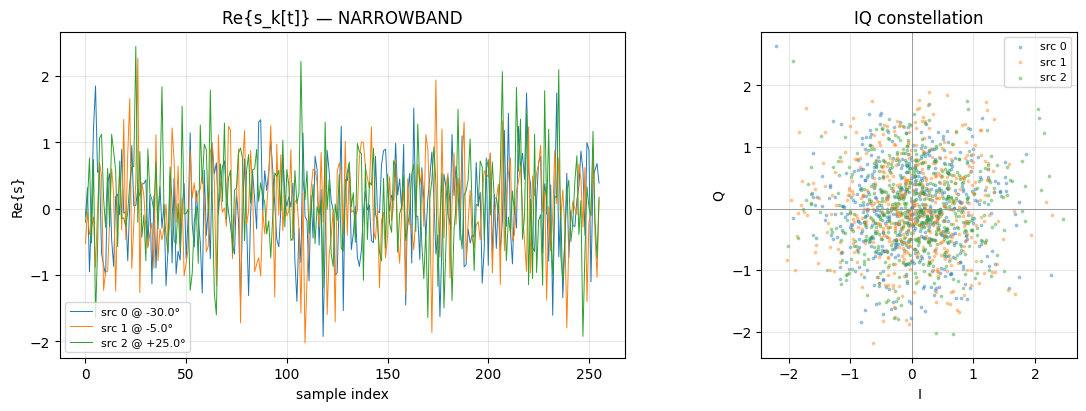

In [2]:
scene = make_scene()
res = renderer.render(scene)
X, R, A, s = res.snapshots, res.covariance, res.steering, res.source_signals

print(f"X shape         : {X.shape}   dtype={X.dtype}")
print(f"R shape         : {R.shape}   Hermitian err = {np.max(np.abs(R - R.conj().T)):.2e}")
print(f"A shape         : {A.shape}")
print(f"source_signals  : {s.shape}")
print(f"per-source |s|² : {np.mean(np.abs(s)**2, axis=1)}  (expect ≈ 1)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax = axes[0]
for k in range(scene.n_sources):
    ax.plot(np.real(s[k, :256]), lw=0.7, label=f"src {k} @ {scene.angles_deg[k]:+.1f}°")
ax.set_title(f"Re{{s_k[t]}} — {ModulationType(int(scene.modulation)).name}")
ax.set_xlabel("sample index"); ax.set_ylabel("Re{s}")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
for k in range(scene.n_sources):
    ax.scatter(s[k].real, s[k].imag, s=3, alpha=0.35,
               label=f"src {k}")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal")
ax.set_title("IQ constellation")
ax.set_xlabel("I"); ax.set_ylabel("Q")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()


## 2. Array snapshots `X` and sample covariance `R`

The observation model is simply

$$
\mathbf{X} = \mathbf{A}\,\mathbf{s} + \mathbf{n},\qquad
\mathbf{R} = \tfrac{1}{T}\,\mathbf{X}\mathbf{X}^{\mathsf{H}}.
$$

Two quick visuals:

* **`X[0]` vs `X[1]`** (left): the first two array elements over time.
  Because sources arrive at different angles, the two traces are **phase-
  shifted** copies of each other (plus independent noise).  A zero-phase
  delta between elements 0 and 1 at K=1, θ=0° is expected (broadside);
  the delta grows as θ departs from broadside.
* **`|R|`** (right): for a clean ULA with `K ≪ M` this matrix is close to
  Toeplitz, Hermitian, and PSD.


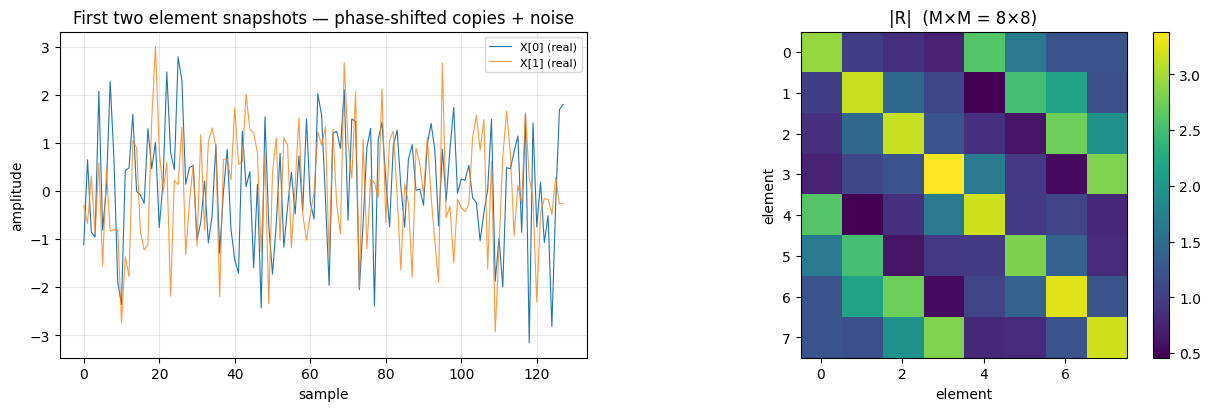

min eig(R)      : +8.015e-02  (must be ≥ -1e-6 for PSD)
max|R - R^H|    : 1.361e-17


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax = axes[0]
ax.plot(np.real(X[0, :128]), lw=0.8, label="X[0] (real)")
ax.plot(np.real(X[1, :128]), lw=0.8, label="X[1] (real)", alpha=0.8)
ax.set_title("First two element snapshots — phase-shifted copies + noise")
ax.set_xlabel("sample"); ax.set_ylabel("amplitude")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
im = ax.imshow(np.abs(R), cmap="viridis")
ax.set_title(f"|R|  (M×M = {R.shape[0]}×{R.shape[1]})")
ax.set_xlabel("element"); ax.set_ylabel("element")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

# Quick PSD / Hermitian check
eigs = np.linalg.eigvalsh(R)
print(f"min eig(R)      : {eigs.min():+.3e}  (must be ≥ -1e-6 for PSD)")
print(f"max|R - R^H|    : {np.max(np.abs(R - R.conj().T)):.3e}")


## 3. Eigenspectrum — the "K above the floor" rule

If there are $K$ direct sources and no multipath, the sample covariance
has exactly $K$ eigenvalues above the noise floor (up to finite-$T$
jitter) — this is the fact that MUSIC/ESPRIT exploits.

Multipath breaks this count: each correlated bounce adds a column to $A$
and the signal subspace grows.  Check both cases below.


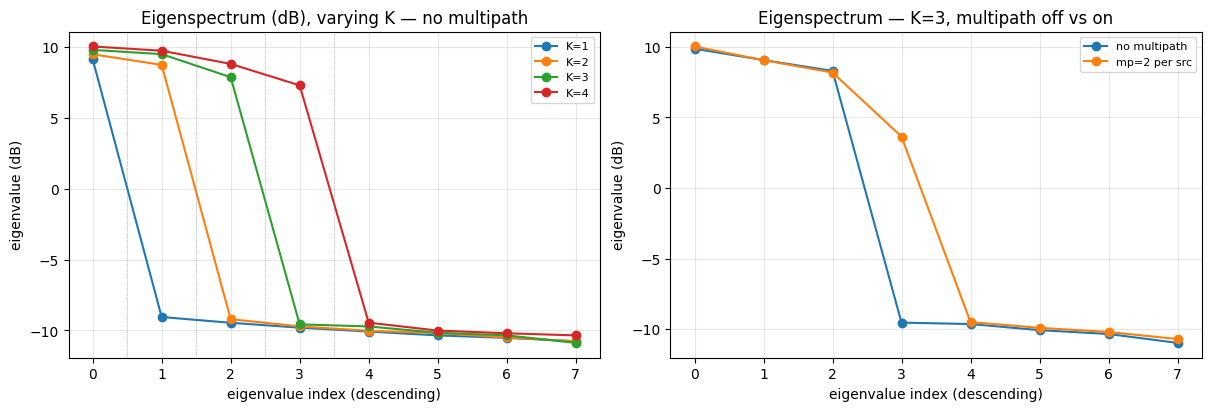

In [4]:
def eig_spectrum_dB(R):
    w = np.linalg.eigvalsh(R)[::-1]          # descending
    return 10 * np.log10(np.maximum(w, 1e-12))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# --- No multipath, varying K
ax = axes[0]
for k in (1, 2, 3, 4):
    ang = np.full(K_MAX, np.nan, dtype=np.float32)
    ang[:k] = np.linspace(-40, 40, k).astype(np.float32)
    sc = make_scene(k=k, angles=ang, has_mp=False)
    w_db = eig_spectrum_dB(renderer.render(sc).covariance)
    ax.plot(w_db, marker="o", label=f"K={k}")
    ax.axvline(k - 0.5, color="gray", ls=":", lw=0.5)
ax.set_title("Eigenspectrum (dB), varying K — no multipath")
ax.set_xlabel("eigenvalue index (descending)")
ax.set_ylabel("eigenvalue (dB)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

# --- Multipath on / off, fixed K
ax = axes[1]
for has_mp, n_mp, lbl in [(False, 0, "no multipath"),
                          (True,  2, "mp=2 per src")]:
    sc = make_scene(has_mp=has_mp, n_mp=n_mp)
    w_db = eig_spectrum_dB(renderer.render(sc).covariance)
    ax.plot(w_db, marker="o", label=lbl)
ax.set_title(f"Eigenspectrum — K={K}, multipath off vs on")
ax.set_xlabel("eigenvalue index (descending)")
ax.set_ylabel("eigenvalue (dB)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()


## 4. Side-by-side K sweep — |R| and the signal subspace

Same scene preset, vary $K$.  The number of bright sub-diagonals in
$|R|$ should grow with $K$, and the number of eigenvalues above the
noise floor should equal $K$.


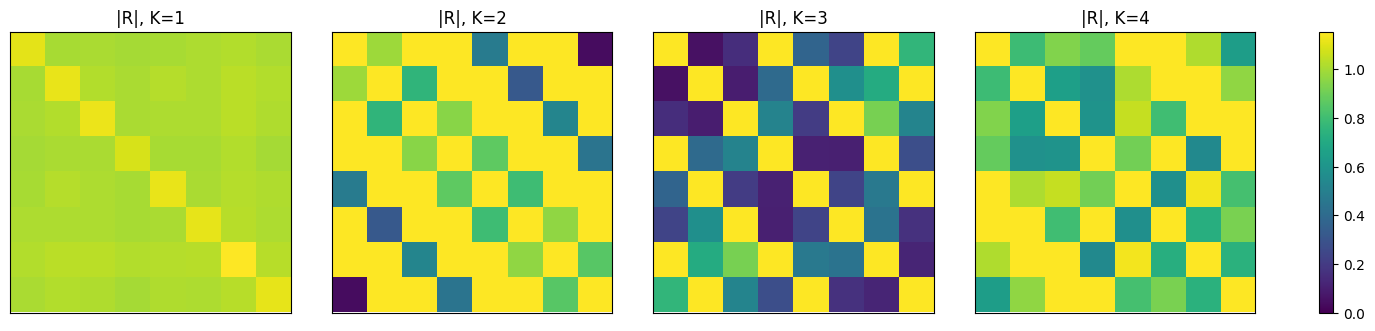

In [5]:
Ks = [1, 2, 3, 4]
fig, axes = plt.subplots(1, len(Ks), figsize=(3.5 * len(Ks), 3.2),
                         constrained_layout=True)
vmax = None
for ax, k in zip(axes, Ks):
    ang = np.full(K_MAX, np.nan, dtype=np.float32)
    ang[:k] = np.linspace(-40, 40, k).astype(np.float32)
    sc = make_scene(k=k, angles=ang)
    R_k = renderer.render(sc).covariance
    im = ax.imshow(np.abs(R_k), cmap="viridis", vmin=0,
                   vmax=(vmax if vmax is not None else np.abs(R_k).max()))
    if vmax is None:
        vmax = np.abs(R_k).max()
    ax.set_title(f"|R|, K={k}")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.03)
plt.show()


## 5. Multipath — what changes in `A`, `s` and `R`

When `has_multipath=True`, the renderer augments `A` and `s` with
`num_multipath` extra columns per direct source.  The ported legacy
convention (see `scene_renderer._sample_multipath_params`):

* each extra path has AoA drawn uniformly on `[0, 2π)` (wraps into
  broadside angles), a delay drawn from `uniform(0, mp_max_delay_factor / fs)`
  or an exponential, a Rayleigh-distributed amplitude loss (from the
  legacy dB formula) and a uniform phase;
* SNR is still measured against **direct-path** signal power — so the
  stored `snr_db` does *not* drift when you toggle multipath.

Run the cell below to compare two R's (multipath off vs on) side by
side — and pay attention to the secondary peaks that appear in $|R|$.


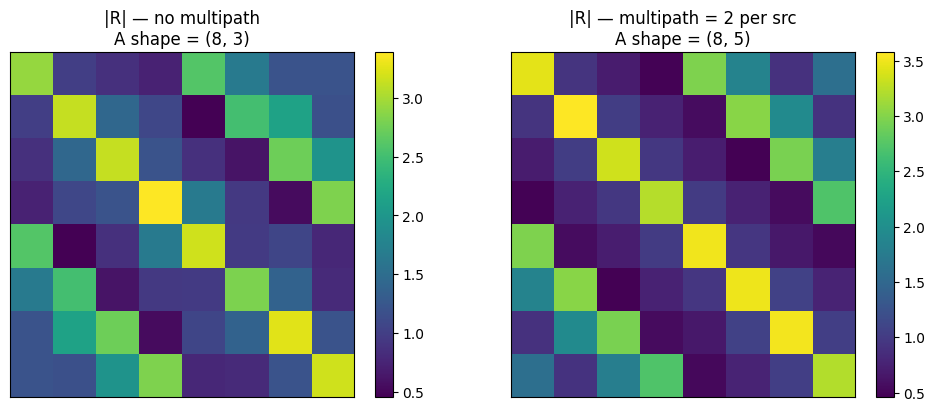

#eig > noise(-3dB from peak)  off: 3  on : 3   (expect 3 off, up to 9 on)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
titles = ["no multipath", f"multipath = {NUM_MULTIPATH} per src"]
for ax, has_mp, title in zip(axes, [False, True], titles):
    sc = make_scene(has_mp=has_mp, n_mp=NUM_MULTIPATH)
    res_mp = renderer.render(sc)
    im = ax.imshow(np.abs(res_mp.covariance), cmap="viridis")
    ax.set_title(f"|R| — {title}\nA shape = {res_mp.steering.shape}")
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

# Print: does the eigengap widen when we turn multipath on?
w_off = np.linalg.eigvalsh(renderer.render(make_scene(has_mp=False)).covariance)[::-1]
w_on  = np.linalg.eigvalsh(renderer.render(
    make_scene(has_mp=True,  n_mp=NUM_MULTIPATH)).covariance)[::-1]
print(f"#eig > noise(-3dB from peak)  off: "
      f"{int((w_off > 10**(-0.3) * w_off[0]).sum())}  "
      f"on : {int((w_on  > 10**(-0.3) * w_on[0]).sum())}   "
      f"(expect {K} off, up to {K*(1+NUM_MULTIPATH)} on)")


## 6. SNR bookkeeping

The renderer sets `noise_var = 1 / 10^(snr_db/10)` against **unit-power
per-source** signals.  So when K independent sources sum at each
element, the per-element total signal power is $K$, giving a
`+10·log10(K)` bias between `scene.snr_db` (per-source SNR) and what a
naive per-element $P_s / P_n$ measurement reports.

**This is not a bug.**  It matches the legacy `add_noise` convention
and the DOA literature's per-source SNR.  For a real bug, look for a
bias of *exactly* 3 dB (complex-vs-real noise-power confusion) or a
bias that depends on the SNR *level* (rather than only on $K$).


In [7]:
rows = []
for k in (1, 2, 3, 4):
    ang = np.full(K_MAX, np.nan, dtype=np.float32)
    ang[:k] = np.linspace(-40, 40, k).astype(np.float32)
    sc  = make_scene(k=k, angles=ang, has_mp=False)
    res = renderer.render(sc)
    P_s = np.mean(np.abs(res.steering @ res.source_signals) ** 2)
    P_n = np.mean(np.abs(res.noise) ** 2)
    measured = 10 * np.log10(P_s / P_n)
    expected = SNR_DB + 10 * np.log10(k)
    rows.append((k, SNR_DB, measured, expected, measured - expected))

print(f"{'K':>3}  {'requested':>10}  {'measured':>10}  {'expected':>10}  {'delta':>8}")
for k, r, m, e, d in rows:
    print(f"{k:>3}  {r:>10.2f}  {m:>10.2f}  {e:>10.2f}  {d:>+8.3f} dB")
print("\nThe 'delta' column should be within ±0.5 dB for T=512.")


  K   requested    measured    expected     delta
  1       10.00       10.05       10.00    +0.045 dB
  2       10.00       13.10       13.01    +0.089 dB
  3       10.00       14.82       14.77    +0.047 dB
  4       10.00       16.01       16.02    -0.011 dB

The 'delta' column should be within ±0.5 dB for T=512.


## 7. Reproducibility

Same seed → byte-identical observations.  Run the cell twice; you should
see `0.0`.


In [8]:
X1 = renderer.render(make_scene()).snapshots
X2 = renderer.render(make_scene()).snapshots
print(f"max |X1 - X2| = {np.max(np.abs(X1 - X2)):.3e}  (expect 0.0)")


max |X1 - X2| = 0.000e+00  (expect 0.0)
